# RideWise · Notebook 04 — Customer Segmentation

**Group riders into a handful of coherent personas with K-means, choose k properly, and name the segments for the business.**

---

### What you will learn
- How to scale RFM features for distance-based clustering
- How to choose the number of clusters with the silhouette score
- How to profile and name segments so marketing can act on them
- How segment membership relates to churn risk

### How to read this notebook
Every section follows the same rhythm used throughout the project:
**the business question first**, then the data, then the method, then a
**validation check** that proves the step did what we claimed. Run the cells
top to bottom; nothing depends on hidden state.

---

## 1. The business question

Retention budget is wasted when it is sprayed evenly. **Which riders behave
alike?** If we can describe ten thousand riders as four personas, marketing can
design four strategies instead of ten thousand. That is what clustering buys us.

In [1]:
# --- environment setup ---
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Project-wide constants used throughout the notebooks
RANDOM_STATE = 42                            # Set a random seed for reproducibility
CHURN_WINDOW_DAYS = 30                       # inactivity window that defines churn
LOYALTY_ORDER = {"Bronze": 0, "Silver": 1, "Gold": 2, "Platinum": 3}            # Define loyalty tier order for sorting and analysis

# Where the raw CSVs live (this notebook sits in notebooks/, data in ../data/)
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")        # Define the data directory path based on the current working directory

NAVY, ACCENT = "#1F3A5F", "#C8843C"                                         # Define color palette for plots
print("Libraries imported · data directory:", DATA_DIR.resolve())

Libraries imported · data directory: C:\Users\woro_\OneDrive\DS_Projects\Ride-hailing_Analytics_and_Churn_Prediction\data


In [2]:
# --- load the analytics table produced by Notebook 03 (chain-via-disk) ---
# Notebook 03 saved ../data/analytics_table.csv; we read it here so this
# notebook runs locally without rebuilding the whole feature pipeline.
df = pd.read_csv(DATA_DIR / 'analytics_table.csv')

print("Riders:", f"{len(df):,}")
print("\nBehavioural summary (RFM core):")
print(df[["recency", "frequency", "monetary"]].describe().round(1))

Riders: 10,000

Behavioural summary (RFM core):
       recency  frequency  monetary
count  10000.0    10000.0   10000.0
mean      17.6       18.4     282.9
std       18.0        4.3      71.8
min        0.0        5.0      67.7
25%        5.0       15.0     232.8
50%       12.0       18.0     279.6
75%       25.0       21.0     329.6
max      160.0       40.0     631.2


## 2. Why scale, and why log first

K-means uses Euclidean distance, so a feature with a big numeric range (like
monetary, in hundreds) would dominate one with a small range (recency, in days).
We **log-transform** to tame skew, then **standardise** so each feature
contributes fairly.

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
rfm = df[["recency", "frequency", "monetary"]]
X = StandardScaler().fit_transform(np.log1p(rfm))
print("Scaled feature means (≈0) and stds (≈1):")
print("means:", X.mean(axis=0).round(3), " stds:", X.std(axis=0).round(3))

Scaled feature means (≈0) and stds (≈1):
means: [ 0.  0. -0.]  stds: [1. 1. 1.]


## 3. Choosing k with the silhouette score

The silhouette score measures how tight and well-separated clusters are
(higher is better, max 1.0). We try several k and pick a value that is both
statistically reasonable and **useful to the business** — too many segments are
as useless as too few.

k=2: silhouette=0.366
k=3: silhouette=0.337
k=4: silhouette=0.319
k=5: silhouette=0.309
k=6: silhouette=0.297


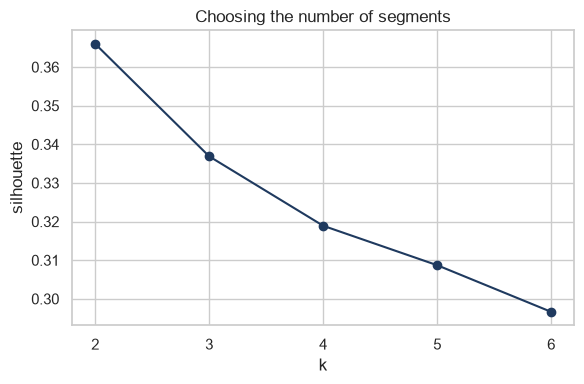

In [4]:
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ensure the output folder exists before saving
VIZ_DIR = Path("../visualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    scores[k] = silhouette_score(X, km.labels_)

for k, s in scores.items():
    print(f"k={k}: silhouette={s:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(list(scores.keys()), list(scores.values()), "o-", color=NAVY)
plt.xlabel("k"); plt.ylabel("silhouette"); plt.title("Choosing the number of segments")
plt.xticks(list(scores.keys()))                       # integer ticks for k
plt.tight_layout()
plt.savefig(VIZ_DIR / "04_k_silhouette.png", dpi=130, bbox_inches="tight")
plt.show()

**Decision:** k=2 scores highest numerically, but two segments is too blunt for
targeted marketing. **k=4** keeps a strong score while giving four actionable
personas — the right trade-off between statistics and business value.

In [5]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X)
df["segment"] = km.labels_
df["segment"].value_counts().sort_index()

segment
0    3481
1    1888
2    2579
3    2052
Name: count, dtype: int64

## 4. Profile and name the segments

In [6]:
profile = df.groupby("segment").agg(
    riders=("user_id", "size"),
    recency=("recency", "mean"),
    frequency=("frequency", "mean"),
    monetary=("monetary", "mean"),
    churn_rate=("churn", "mean"),
).round(2)
profile["share_%"] = (profile["riders"] / profile["riders"].sum() * 100).round(1)
profile

,riders,recency,frequency,monetary,churn_rate,share_%
segment,,,,,,
0,3481,26.02,17.67,271.32,0.34,34.8
1,1888,24.91,12.56,187.09,0.56,18.9
2,2579,13.30,23.49,369.05,0.11,25.8
3,2052,2.24,18.46,282.45,0.18,20.5


**Worked example — naming from the numbers.** Read each row and assign a human
label. Low recency + high frequency + high spend + low churn = your best
customers ("Champions"). High churn + low value = "At-Risk Low-Value". Apply the
same logic to the remaining rows. The names below are derived from the profile —
re-check them against your run, since cluster ids can permute between runs.

In [7]:
# Derive names from the profile rather than hard-coding, so it survives re-runs
def name_segment(row):
    if row["churn_rate"] >= 0.45:
        return "At-Risk Low-Value"
    if row["recency"] <= 8:
        return "New & Engaged"
    if row["churn_rate"] <= 0.20 and row["monetary"] >= profile["monetary"].median():
        return "Champions"
    return "Lapsing Mid-Value"

profile["segment_name"] = profile.apply(name_segment, axis=1)
name_map = profile["segment_name"].to_dict()
df["segment_name"] = df["segment"].map(name_map)
profile[["segment_name", "share_%", "recency", "frequency", "monetary", "churn_rate"]]

,segment_name,share_%,recency,frequency,monetary,churn_rate
segment,,,,,,
0,Lapsing Mid-Value,34.8,26.02,17.67,271.32,0.34
1,At-Risk Low-Value,18.9,24.91,12.56,187.09,0.56
2,Champions,25.8,13.30,23.49,369.05,0.11
3,New & Engaged,20.5,2.24,18.46,282.45,0.18


## 5. Visualise the segments

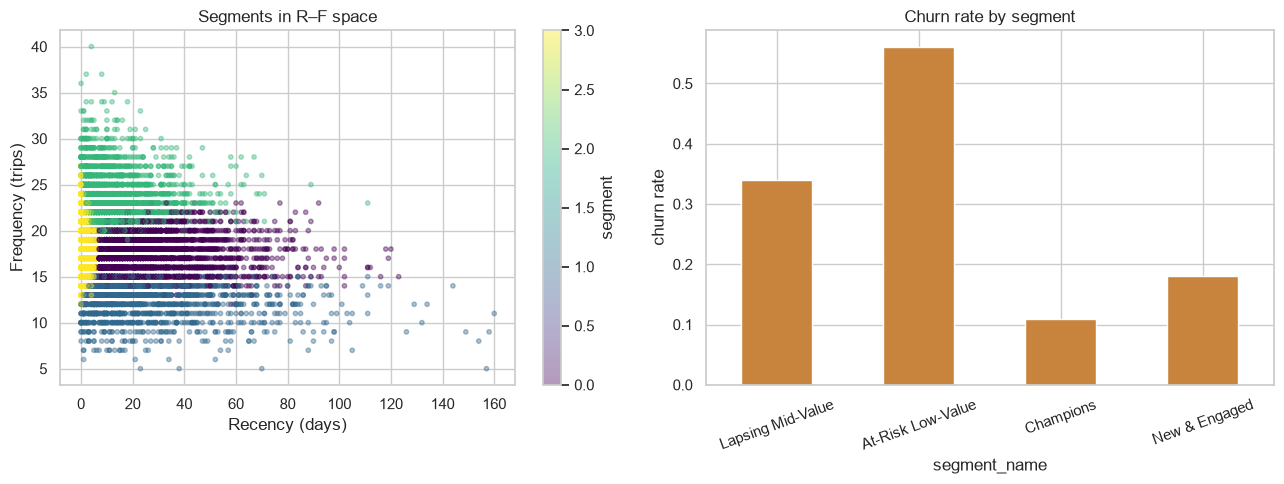

<Figure size 640x480 with 0 Axes>

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(df["recency"], df["frequency"], c=df["segment"], cmap="viridis", alpha=0.4, s=10)
ax[0].set_xlabel("Recency (days)"); ax[0].set_ylabel("Frequency (trips)"); ax[0].set_title("Segments in R–F space")
plt.colorbar(sc, ax=ax[0], label="segment")
profile.set_index("segment_name")["churn_rate"].plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Churn rate by segment"); ax[1].set_ylabel("churn rate"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
plt.savefig('../visualizations/04__segment_categories.png')

## 6. Summary

- Four segments, chosen by silhouette and business usefulness.
- Each has a distinct RFM profile **and** a distinct churn rate — the
  segmentation is not just statistically valid, it is decision-relevant.
- Names are derived from the profile so the logic survives re-runs.

**Next:** Notebook 05 builds the supervised churn models.